<a href="https://colab.research.google.com/github/sidharth2733mba25fin-ops/COLLAB-FILES/blob/main/Lab_2_3_Fairness_Metrics_Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2–3: Fairness Metrics in AI Decision-Making
Ready-made Google Colab notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = {
"Applicant_ID": range(1,21),
"Group": ["A"]*10+["B"]*10,
"Income_Lakhs":[8,10,12,7,15,9,11,14,6,13]*2,
"Credit_Score":[720,750,780,700,810,730,760,790,680,770]*2,
"Existing_EMI_Thousands":[15,12,10,18,8,14,11,9,20,10]*2,
"Loan_Approved":[1,1,1,0,1,1,1,1,0,1,1,0,1,0,1,0,1,0,0,1]
}
df=pd.DataFrame(data)
df

,Applicant_ID,Group,Income_Lakhs,Credit_Score,Existing_EMI_Thousands,Loan_Approved
0,1,A,8,720,15,1
1,2,A,10,750,12,1
2,3,A,12,780,10,1
3,4,A,7,700,18,0
4,5,A,15,810,8,1
5,6,A,9,730,14,1
6,7,A,11,760,11,1
7,8,A,14,790,9,1
8,9,A,6,680,20,0
9,10,A,13,770,10,1


Group
A    0.8
B    0.5
Name: Loan_Approved, dtype: float64


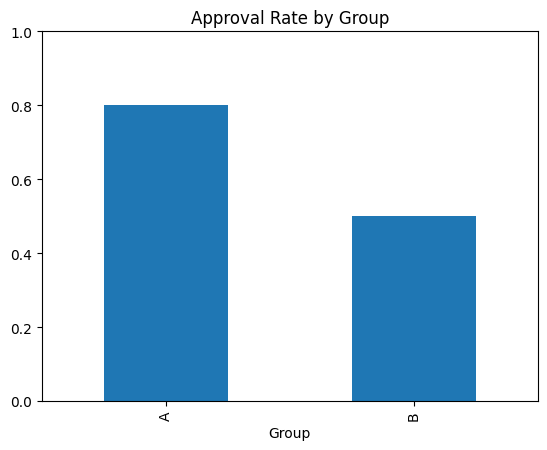

In [ ]:
approval_rate_by_group = df.groupby("Group")["Loan_Approved"].mean()
print(approval_rate_by_group)
approval_rate_by_group.plot(kind='bar', title='Approval Rate by Group')
plt.ylim(0,1); plt.show()

In [ ]:
group_a=approval_rate_by_group['A']
group_b=approval_rate_by_group['B']
ratio=group_b/group_a
print("Disparate Impact Ratio:", ratio)
print("Fairness Concern" if ratio<0.8 else "No major concern")

Disparate Impact Ratio: 0.625
Fairness Concern


Group
A    0.0
B    0.3
Name: False_Rejection, dtype: float64


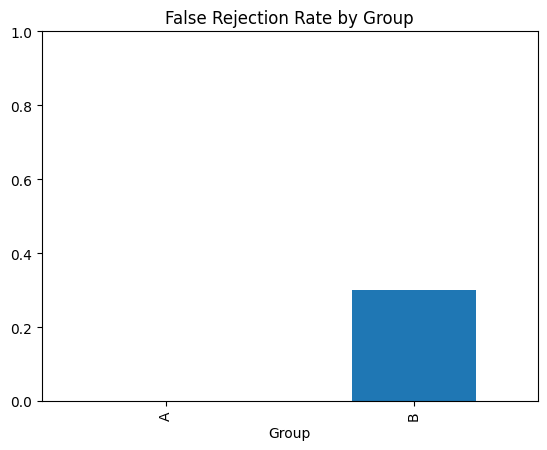

In [ ]:
df["Actually_Good_Borrower"]=[1,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,1]
df["False_Rejection"]=np.where((df["Actually_Good_Borrower"]==1)&(df["Loan_Approved"]==0),1,0)
fr=df.groupby("Group")["False_Rejection"].mean()
print(fr)
fr.plot(kind='bar', title='False Rejection Rate by Group')
plt.ylim(0,1); plt.show()

In [ ]:
print('Conclusion: AI systems should be monitored for fairness, not just accuracy.')

Conclusion: AI systems should be monitored for fairness, not just accuracy.
